In [1]:
!pip install spectral --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 7.7 MB/s eta 0:00:00


In [2]:
import os, random, warnings
import numpy as np
import scipy.io as sio
import scipy.ndimage
import matplotlib.pyplot as plt
import seaborn as sns
import spectral

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, cohen_kappa_score)
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras import utils as np_utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, History
from tensorflow.keras import backend as K

warnings.filterwarnings("ignore")
K.set_image_data_format('channels_last')
print("TF:", tf.__version__)

2026-04-19 15:52:13.200028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776613933.392046      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776613933.447737      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776613933.886902      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776613933.886943      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776613933.886946      55 computation_placer.cc:177] computation placer alr

TF: 2.19.0


In [3]:
# Configuration and class names
DATA_PATH = '/kaggle/input/datasets/rupeshkumaryadav/whu-hyperspectral-dataset/WHU-Hi-LongKou'
NUM_COMPONENTS = 30
WINDOW_SIZE    = 1
TEST_RATIO     = 0.25

CLASS_NAMES = {
    0: "Background",
    1: "Corn",
    2: "Cotton",
    3: "Sesame",
    4: "Broad-Leaf Soybean",
    5: "Narrow-Leaf Soybean",
    6: "Rice",
    7: "Water Body",
    8: "Mixed Weed",
    9: "Roads & Houses"
}
COLORS = [
    '#D62728','#2CA02C','#1F77B4','#BCBD22',
    '#FF7F0E','#E377C2','#17BECF','#9467BD','#8C564B','#7F7F7F'
]
print("Config set.")

Config set.


In [4]:
# Load data
def load_data():
    X = sio.loadmat(os.path.join(DATA_PATH, 'WHU_Hi_LongKou.mat'))['WHU_Hi_LongKou']
    y = sio.loadmat(os.path.join(DATA_PATH, 'WHU_Hi_LongKou_gt.mat'))['WHU_Hi_LongKou_gt']
    return X.astype(np.float32), y

X_raw, y = load_data()
print(f"Hyperspectral cube : {X_raw.shape}  → (H, W, Bands)")
print(f"Ground truth       : {y.shape}")
print(f"Classes            : {np.unique(y)}")
unique_labels, label_counts = np.unique(y, return_counts=True)
for lbl, cnt in zip(unique_labels, label_counts):
    print(f"  Class {lbl:2d} ({CLASS_NAMES.get(lbl,'?'):>22s}): {cnt:>8,} pixels")

Hyperspectral cube : (550, 400, 270)  → (H, W, Bands)
Ground truth       : (550, 400)
Classes            : [0 1 2 3 4 5 6 7 8 9]
  Class  0 (            Background):   15,458 pixels
  Class  1 (                  Corn):   34,511 pixels
  Class  2 (                Cotton):    8,374 pixels
  Class  3 (                Sesame):    3,031 pixels
  Class  4 (    Broad-Leaf Soybean):   63,212 pixels
  Class  5 (   Narrow-Leaf Soybean):    4,151 pixels
  Class  6 (                  Rice):   11,854 pixels
  Class  7 (            Water Body):   67,056 pixels
  Class  8 (            Mixed Weed):    7,124 pixels
  Class  9 (        Roads & Houses):    5,229 pixels


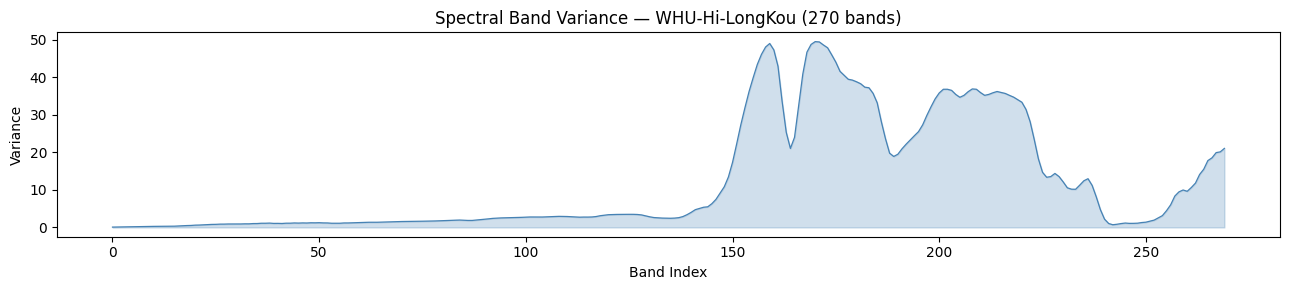

Top 5 most informative bands: [170 171 159 169 172]


In [5]:
# Spectral variance across all pixels — bands with high variance carry discriminative info
band_variance = X_raw.reshape(-1, X_raw.shape[2]).var(axis=0)

plt.figure(figsize=(13, 3))
plt.plot(band_variance, color='steelblue', linewidth=0.9)
plt.fill_between(range(len(band_variance)), band_variance, alpha=0.25, color='steelblue')
plt.title("Spectral Band Variance — WHU-Hi-LongKou (270 bands)", fontsize=12)
plt.xlabel("Band Index"); plt.ylabel("Variance")
plt.tight_layout(); plt.show()
print(f"Top 5 most informative bands: {np.argsort(band_variance)[-5:][::-1]}")

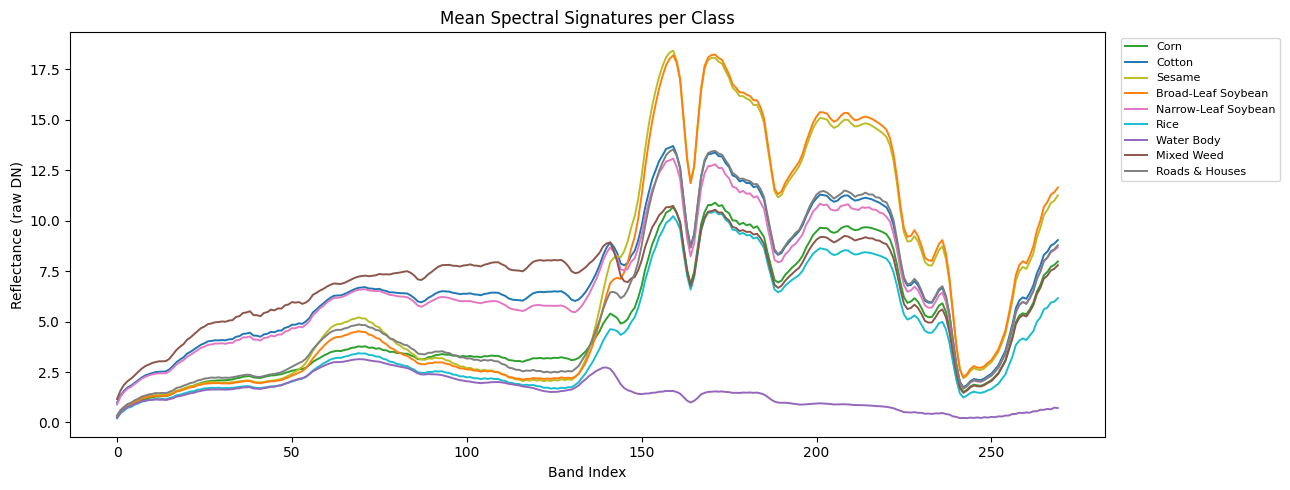

In [6]:
# The canonical HSI figure — mean reflectance curve per crop class
fig, ax = plt.subplots(figsize=(13, 5))
X_flat = X_raw.reshape(-1, X_raw.shape[2])
y_flat = y.ravel()

for cls_id in range(1, 10):
    mask = y_flat == cls_id
    if mask.sum() == 0:
        continue
    mean_spectrum = X_flat[mask].mean(axis=0)
    ax.plot(mean_spectrum, label=CLASS_NAMES[cls_id], color=COLORS[cls_id], linewidth=1.4)

ax.set_title("Mean Spectral Signatures per Class", fontsize=12)
ax.set_xlabel("Band Index"); ax.set_ylabel("Reflectance (raw DN)")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

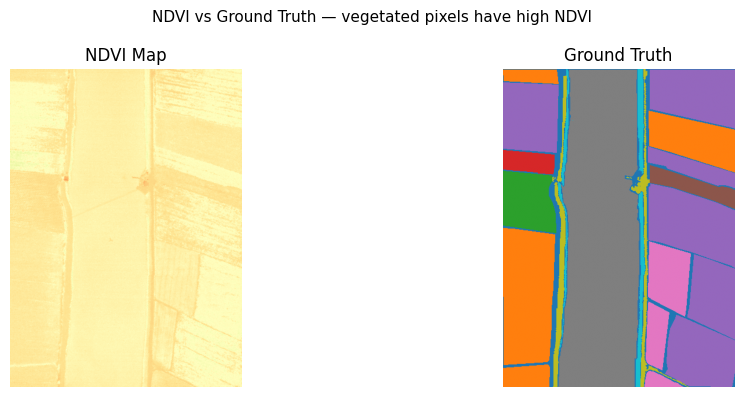

NDVI range: [-0.096, 0.345]


In [7]:
# NDVI Vegetation index
# WHU-Hi-LongKou: NIR ≈ band 55, Red ≈ band 30 (approximate — dataset has 270 bands, ~400–1000 nm)
NIR_BAND = 55
RED_BAND  = 30

nir = X_raw[:, :, NIR_BAND].astype(np.float32)
red = X_raw[:, :, RED_BAND].astype(np.float32)
ndvi = (nir - red) / (nir + red + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.5, vmax=1.0)
axes[0].set_title("NDVI Map"); axes[0].axis('off')
axes[1].imshow(y, cmap='tab10')
axes[1].set_title("Ground Truth"); axes[1].axis('off')
plt.suptitle("NDVI vs Ground Truth — vegetated pixels have high NDVI", fontsize=11)
plt.tight_layout(); plt.show()
print(f"NDVI range: [{ndvi.min():.3f}, {ndvi.max():.3f}]")

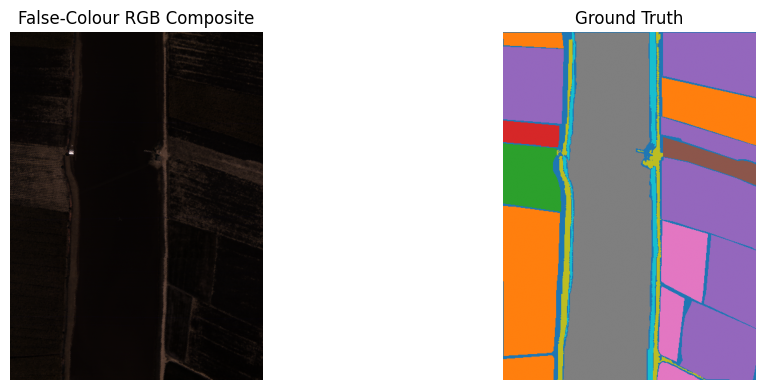

In [8]:
# RGB false color composite
# Bands 50, 30, 10 → pseudo-RGB for visual sanity check
def make_rgb(X, r=50, g=30, b=10):
    rgb = X[:, :, [r, g, b]].copy()
    for i in range(3):
        ch = rgb[:,:,i]
        rgb[:,:,i] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-8)
    return rgb

rgb = make_rgb(X_raw)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rgb); axes[0].set_title("False-Colour RGB Composite"); axes[0].axis('off')
axes[1].imshow(y, cmap='tab10'); axes[1].set_title("Ground Truth"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Explained variance by 30 PCs: 99.98%
PCA output shape: (550, 400, 30)


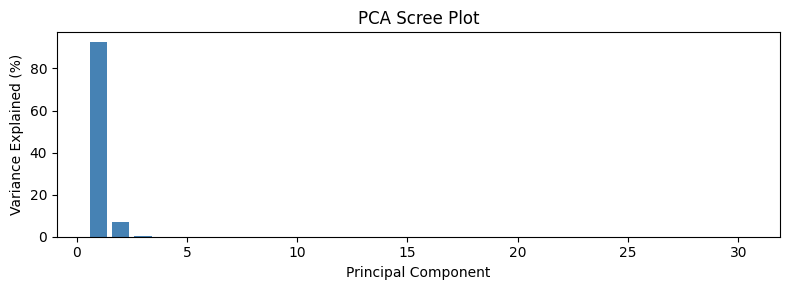

In [9]:
def normalize(X):
    return (X - X.min()) / (X.max() - X.min() + 1e-8)

def apply_pca(X, n_components):
    H, W, B = X.shape
    X_flat = X.reshape(-1, B)
    pca = PCA(n_components=n_components, whiten=True)
    X_reduced = pca.fit_transform(X_flat)
    print(f"Explained variance by {n_components} PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    return X_reduced.reshape(H, W, n_components), pca

X_norm = normalize(X_raw)
X_pca, pca_model = apply_pca(X_norm, NUM_COMPONENTS)
print(f"PCA output shape: {X_pca.shape}")

# Scree plot
plt.figure(figsize=(8, 3))
plt.bar(range(1, NUM_COMPONENTS+1), pca_model.explained_variance_ratio_*100, color='steelblue')
plt.xlabel("Principal Component"); plt.ylabel("Variance Explained (%)")
plt.title("PCA Scree Plot"); plt.tight_layout(); plt.show()

In [11]:
# Patch extraction
def pad_with_zeros(X, margin):
    return np.pad(X, ((margin,margin),(margin,margin),(0,0)), mode='constant')

def create_patches(X, y, window_size=1, remove_zero=True):
    margin = (window_size - 1) // 2
    Xp = pad_with_zeros(X, margin)
    H, W, _ = X.shape
    patches = np.zeros((H*W, window_size, window_size, X.shape[2]), dtype=np.float32)
    labels  = np.zeros(H*W, dtype=np.float32)
    idx = 0
    for r in range(margin, H + margin):
        for c in range(margin, W + margin):
            patches[idx] = Xp[r-margin:r+margin+1, c-margin:c+margin+1, :]
            labels[idx]  = y[r-margin, c-margin]
            idx += 1
    if remove_zero:
        mask = labels > 0
        patches = patches[mask]; labels = labels[mask] - 1
    return patches, labels

Xp, yp = create_patches(X_pca, y, WINDOW_SIZE)
print(f"Patches: {Xp.shape}, Labels: {yp.shape}")

Patches: (204542, 1, 1, 30), Labels: (204542,)


In [12]:
# Train/test split + oversampling + augmentation
def oversample(X, y):
    unique, counts = np.unique(y, return_counts=True)
    max_count = counts.max()
    Xs, ys = [], []
    for lbl, cnt in zip(unique, counts):
        reps = round(max_count / cnt)
        Xs.append(X[y == lbl].repeat(reps, axis=0))
        ys.append(np.full(X[y==lbl].shape[0]*reps, lbl))
    X_new, y_new = np.concatenate(Xs), np.concatenate(ys)
    perm = np.random.permutation(len(y_new))
    return X_new[perm], y_new[perm]

def augment(X):
    for i in range(X.shape[0] // 2):
        num = random.randint(0, 2)
        if num == 0:   X[i] = np.flipud(X[i])
        elif num == 1: X[i] = np.fliplr(X[i])
        else:
            angle = random.randrange(-180, 180, 30)
            X[i] = scipy.ndimage.rotate(X[i], angle, axes=(1,0), reshape=False, order=3, mode='constant')
    return X

X_tr, X_te, y_tr, y_te = train_test_split(Xp, yp, test_size=TEST_RATIO, random_state=345, stratify=yp)
X_tr, y_tr = oversample(X_tr, y_tr)
X_tr = augment(X_tr)

# Reshape for 1D-CNN: (N, bands, 1)
X_tr_1d = X_tr.reshape(X_tr.shape[0], NUM_COMPONENTS, 1)
X_te_1d = X_te.reshape(X_te.shape[0], NUM_COMPONENTS, 1)
y_tr_cat = np_utils.to_categorical(y_tr, num_classes=9)
y_te_cat = np_utils.to_categorical(y_te, num_classes=9)
print(f"Train: {X_tr_1d.shape}, Test: {X_te_1d.shape}")

Train: (451942, 30, 1), Test: (51136, 30, 1)


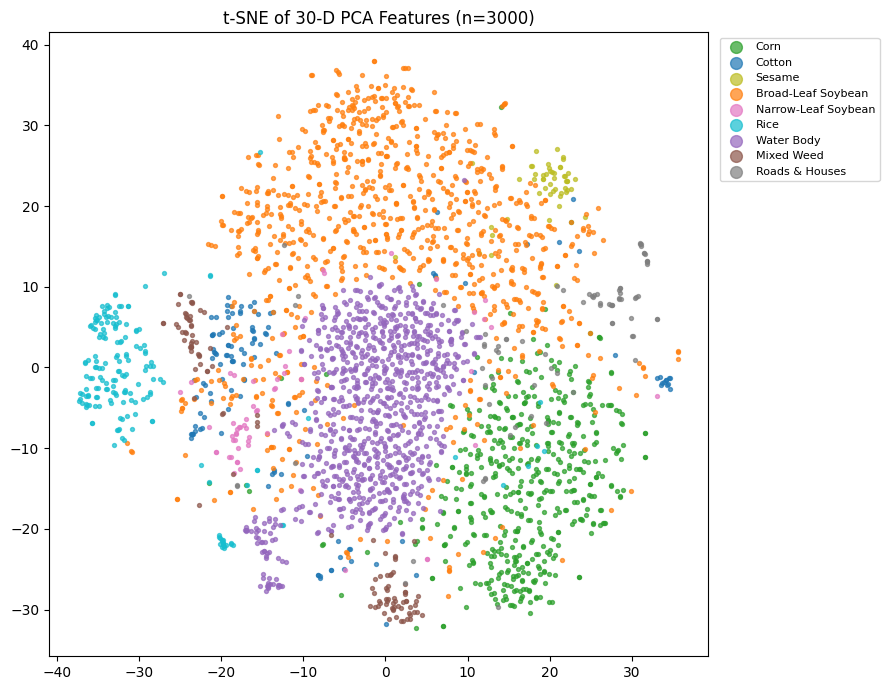

In [13]:
# Sample 3000 points for speed — t-SNE on 200k points would take hours
np.random.seed(42)
sample_idx = np.random.choice(len(yp), 3000, replace=False)
X_sample = Xp[sample_idx].reshape(3000, -1)
y_sample = yp[sample_idx].astype(int)

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=500)
X_2d = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 7))
for cls_id in range(9):
    mask = y_sample == cls_id
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=COLORS[cls_id+1], label=CLASS_NAMES[cls_id+1],
                s=8, alpha=0.7)
plt.title("t-SNE of 30-D PCA Features (n=3000)", fontsize=12)
plt.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()

In [ ]:
# Build & train 1D-CNN
model = Sequential([
    Conv1D(20, kernel_size=3, activation='relu', padding='same', input_shape=(NUM_COMPONENTS, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(9, activation='softmax')
])
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, min_delta=1e-5)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_tr_1d, y_tr_cat,
    batch_size=64, epochs=100,
    validation_data=(X_te_1d, y_te_cat),
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 30, 20)         │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,769 (155.35 KB)

 Trainable params: 39,769 (155.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9483 - loss: 0.1772 - val_accuracy: 0.9824 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 2/100
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9914 - loss: 0.0278 - val_accuracy: 0.9799 - val_loss: 0.0685 - learning_rate: 0.0010
Epoch 3/100
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9946 - loss: 0.0175 - val_accuracy: 0.9895 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 4/100
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9962 - loss: 0.0129 - val_accuracy: 0.9878 - val_loss: 0.0465 - learning_rate: 0.0010
Epoch 5/100
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy: 0.9968 - loss: 0.0103 - val_accuracy: 0.9910 - val_loss: 0.0363 - learning_rate: 0.0010
Epoch 6/100
7059/7062 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9974 - loss: 0.0085
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7062/7062 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step - accuracy:

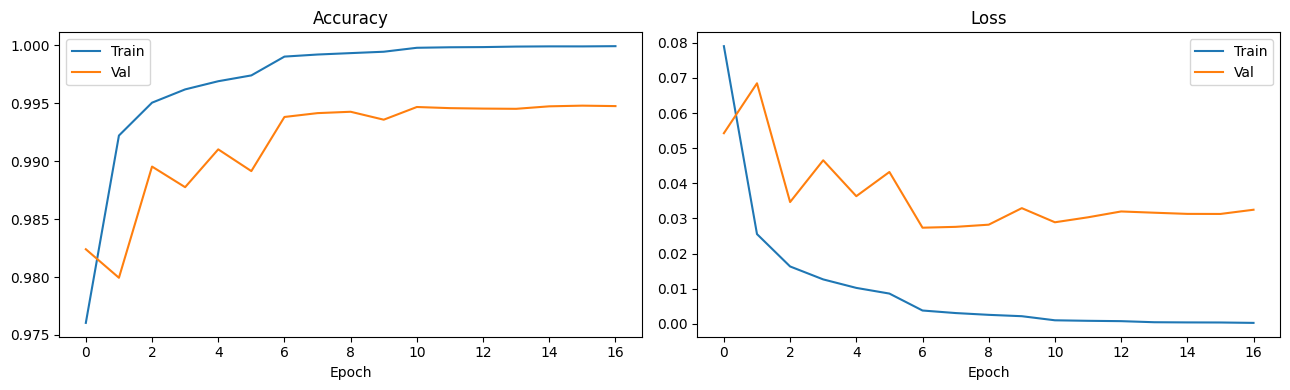

In [17]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'],     label='Train'); axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'],         label='Train'); axes[1].plot(history.history['val_loss'],     label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

In [18]:
scores = model.evaluate(X_te_1d, y_te_cat, verbose=0)
print(f"Test Accuracy: {scores[1]*100:.2f}%")

y_pred_prob = model.predict(X_te_1d)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_te_cat, axis=1)

# Overall Accuracy, Average Accuracy, Cohen's Kappa — standard HSI metrics
OA    = (y_pred == y_true).mean()
per_class_acc = [((y_pred==c) & (y_true==c)).sum() / (y_true==c).sum() for c in range(9)]
AA    = np.mean(per_class_acc)
kappa = cohen_kappa_score(y_true, y_pred)
print(f"\n{'='*40}")
print(f"  Overall Accuracy  (OA)  : {OA*100:.2f}%")
print(f"  Average Accuracy  (AA)  : {AA*100:.2f}%")
print(f"  Cohen Kappa       (κ)   : {kappa:.4f}")
print(f"{'='*40}")

print("\nClassification Report:\n")
target_names = [CLASS_NAMES[i+1] for i in range(9)]
print(classification_report(y_true, y_pred, target_names=target_names))

Test Accuracy: 99.38%
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

  Overall Accuracy  (OA)  : 99.38%
  Average Accuracy  (AA)  : 98.66%
  Cohen Kappa       (κ)   : 0.9919

Classification Report:

                     precision    recall  f1-score   support

               Corn       0.99      1.00      1.00      8628
             Cotton       0.97      0.98      0.98      2093
             Sesame       0.98      0.97      0.98       758
 Broad-Leaf Soybean       0.99      0.99      0.99     15803
Narrow-Leaf Soybean       0.96      0.97      0.97      1038
               Rice       1.00      1.00      1.00      2964
         Water Body       1.00      1.00      1.00     16764
         Mixed Weed       0.99      0.98      0.98      1781
     Roads & Houses       0.97      0.99      0.98      1307

           accuracy                           0.99     51136
          macro avg       0.98      0.99      0.99     51136
       weighted avg       0.99      0.99      0.99     51136



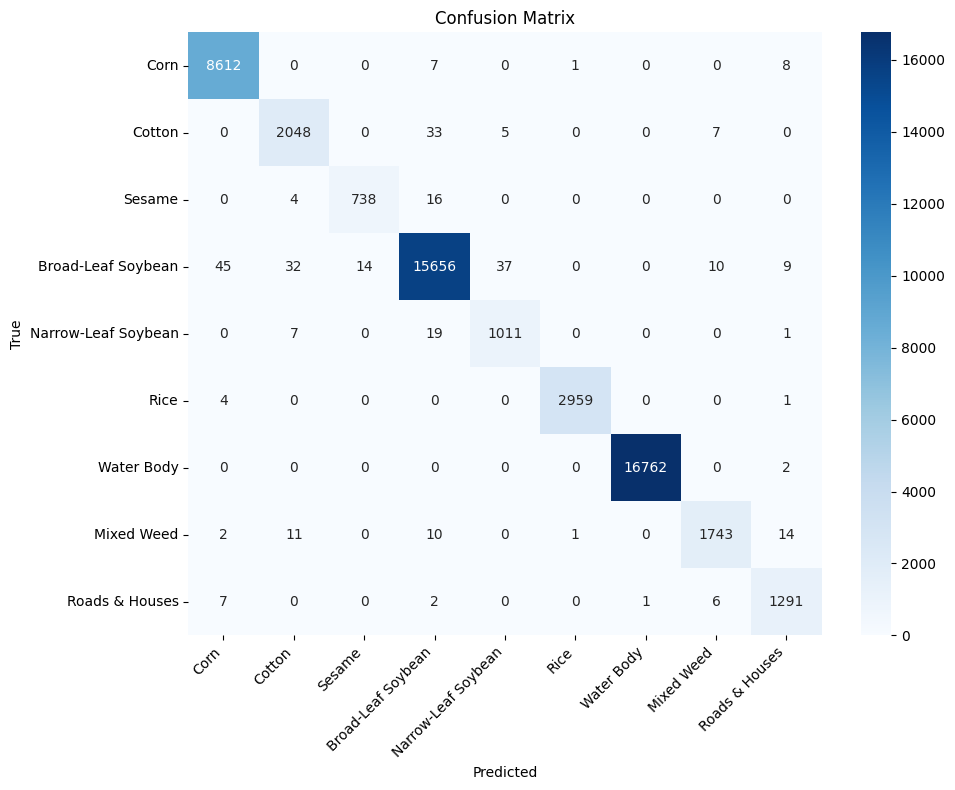

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[i+1] for i in range(9)],
            yticklabels=[CLASS_NAMES[i+1] for i in range(9)])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

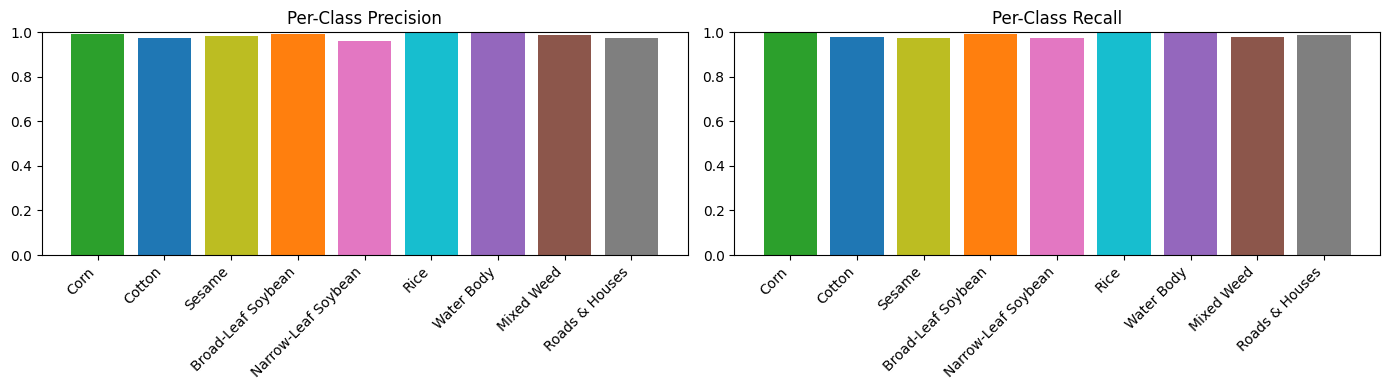

In [20]:
# Per-class precision and recall
precision, recall, _, _ = precision_recall_fscore_support(y_true, y_pred)
x = np.arange(9)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(x, precision, color=[COLORS[i+1] for i in range(9)])
axes[0].set_xticks(x); axes[0].set_xticklabels([CLASS_NAMES[i+1] for i in range(9)], rotation=45, ha='right')
axes[0].set_title('Per-Class Precision'); axes[0].set_ylim(0, 1)
axes[1].bar(x, recall, color=[COLORS[i+1] for i in range(9)])
axes[1].set_xticks(x); axes[1].set_xticklabels([CLASS_NAMES[i+1] for i in range(9)], rotation=45, ha='right')
axes[1].set_title('Per-Class Recall'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

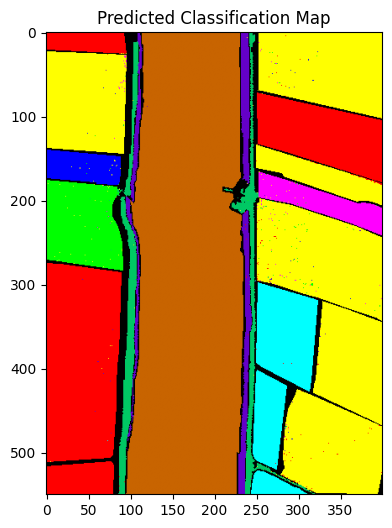

In [21]:
# Full spatial prediction map
PATCH_SIZE = 1
height, width = y.shape

def get_pixel_patch(X_pca, i, j, patch_size=1):
    return X_pca[i:i+patch_size, j:j+patch_size, :]

patches_inf, positions = [], []
for i in range(height):
    for j in range(width):
        if y[i, j] == 0:
            continue
        patch = X_pca[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :].reshape(1, NUM_COMPONENTS, 1)
        patches_inf.append(patch)
        positions.append((i, j))

patches_inf = np.concatenate(patches_inf, axis=0)
preds = model.predict(patches_inf, batch_size=1024, verbose=0)

outputs = np.zeros((height, width))
for pred, (r, c) in zip(preds, positions):
    outputs[r][c] = np.argmax(pred) + 1

spectral.imshow(classes=outputs.astype(int), figsize=(6, 6))
plt.title("Predicted Classification Map"); plt.show()